In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, f1_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.metrics.pairwise import pairwise_distances
import optuna
from knn_handmade import KNNHandMade
%matplotlib inline

### Загрузка данных

In [77]:
data = pd.read_csv('data/k4_eda.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62567 entries, 0 to 62566
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   UTC             62567 non-null  int64  
 1   Temperature[C]  62567 non-null  float64
 2   Humidity[%]     62567 non-null  float64
 3   TVOC[ppb]       62567 non-null  float64
 4   eCO2[ppm]       62567 non-null  float64
 5   Raw H2          62567 non-null  int64  
 6   Raw Ethanol     62567 non-null  int64  
 7   Pressure[hPa]   62567 non-null  float64
 8   PM1.0           62567 non-null  float64
 9   PM2.5           62567 non-null  float64
 10  NC0.5           62567 non-null  float64
 11  NC1.0           62567 non-null  float64
 12  NC2.5           62567 non-null  float64
 13  Fire Alarm      62567 non-null  bool   
dtypes: bool(1), float64(10), int64(3)
memory usage: 6.3 MB


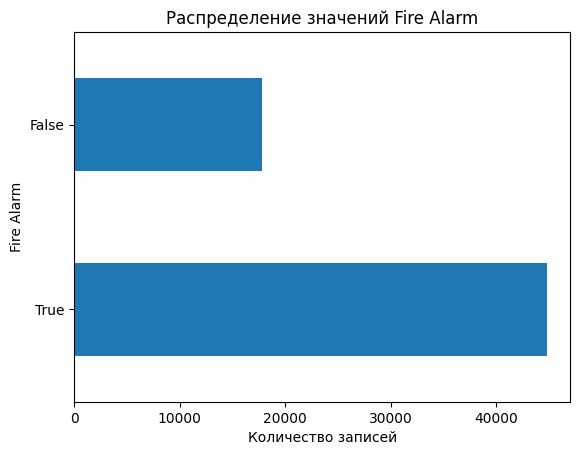

In [78]:
data['Fire Alarm'].value_counts().plot(kind='barh')
plt.title('Распределение значений Fire Alarm')
plt.xlabel('Количество записей')
plt.ylabel('Fire Alarm')
plt.show()

### Балансировка классов

In [79]:
feature_data = data.drop(['Fire Alarm'], axis=1)
labels_data = data['Fire Alarm']
oversample = SMOTE()
transformed_feature_data, transformed_labels_data = oversample.fit_resample(feature_data, labels_data)

In [80]:
print("Распределение классов после SMOTE:")
print(transformed_labels_data.value_counts())

Распределение классов после SMOTE:
Fire Alarm
False    44757
True     44757
Name: count, dtype: int64


### Объединение и перемешивание данных

In [81]:
data_balanced = pd.concat([transformed_feature_data, transformed_labels_data], axis=1)
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
data_balanced.to_csv('data/k4_balanced.csv', index=False)

### Подготовка данных

In [82]:
X = data_balanced.drop(columns=['Fire Alarm', 'UTC'])
y = data_balanced['Fire Alarm']
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Функция для оценки модели

In [83]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    y_scores = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    print(f"\n--- {model_name} ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"F1-score: {f1_score(y_test, y_pred):.4f}")
    
    if y_scores is not None:
        fpr, tpr, _ = roc_curve(y_test, y_scores)
        auc = roc_auc_score(y_test, y_scores)
        plt.figure(figsize=(6, 6))
        plt.plot([0, 1], [0, 1], 'k--')
        plt.plot(fpr, tpr)
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve for {model_name} (AUC = {auc:.2f})')
        plt.show()
        print(f"AUC: {auc:.2f}")

### Logistic Regression


--- Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.93      0.90     13428
        True       0.92      0.88      0.90     13427

    accuracy                           0.90     26855
   macro avg       0.90      0.90      0.90     26855
weighted avg       0.90      0.90      0.90     26855

Confusion Matrix:
[[12447   981]
 [ 1673 11754]]
F1-score: 0.8986


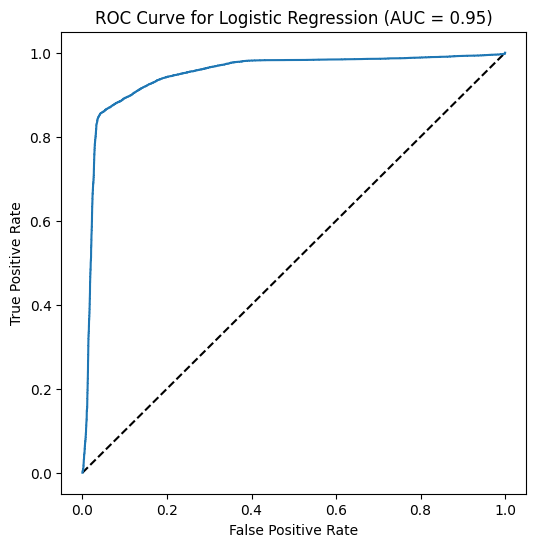

AUC: 0.95


In [84]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
evaluate_model(logreg, X_test, y_test, "Logistic Regression")

In [85]:
def objective_logreg(trial):
    C = trial.suggest_loguniform('C', 1e-3, 1e3)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    model = LogisticRegression(C=C, penalty=penalty, solver='liblinear', random_state=42)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()

[I 2025-06-05 19:30:10,068] A new study created in memory with name: no-name-f9172ca1-cc3e-4621-88d2-6a2279c5fe7e
C:\Users\andre\AppData\Local\Temp\ipykernel_21744\3469733965.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 1e-3, 1e3)
[I 2025-06-05 19:30:11,056] Trial 0 finished with value: 0.905967205798181 and parameters: {'C': 0.10980066756767477, 'penalty': 'l1'}. Best is trial 0 with value: 0.905967205798181.
C:\Users\andre\AppData\Local\Temp\ipykernel_21744\3469733965.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform('C', 1e-3, 1e3)
[I 2025-06-05 19:30:11,641] Trial 1 finished with value: 0.906238

Лучшие параметры для Logistic Regression: {'C': 0.0011407799502494878, 'penalty': 'l2'}

--- Logistic Regression (Optimized) ---
Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.95      0.91     13428
        True       0.95      0.86      0.90     13427

    accuracy                           0.91     26855
   macro avg       0.91      0.91      0.91     26855
weighted avg       0.91      0.91      0.91     26855

Confusion Matrix:
[[12783   645]
 [ 1878 11549]]
F1-score: 0.9015


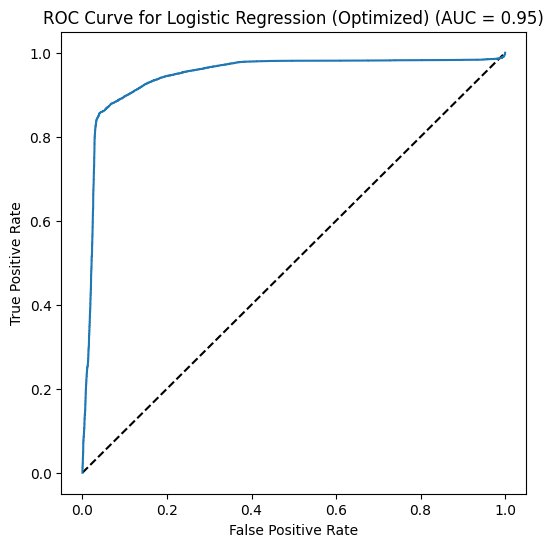

AUC: 0.95


In [86]:
study_logreg = optuna.create_study(direction='maximize')
study_logreg.optimize(objective_logreg, n_trials=50)
print("Лучшие параметры для Logistic Regression:", study_logreg.best_params)
logreg_best = LogisticRegression(**study_logreg.best_params, solver='liblinear', random_state=42)
logreg_best.fit(X_train, y_train)
evaluate_model(logreg_best, X_test, y_test, "Logistic Regression (Optimized)")

### Naive Bayes


--- Naive Bayes ---
Classification Report:
              precision    recall  f1-score   support

       False       0.86      0.98      0.92     13428
        True       0.98      0.84      0.90     13427

    accuracy                           0.91     26855
   macro avg       0.92      0.91      0.91     26855
weighted avg       0.92      0.91      0.91     26855

Confusion Matrix:
[[13193   235]
 [ 2207 11220]]
F1-score: 0.9019


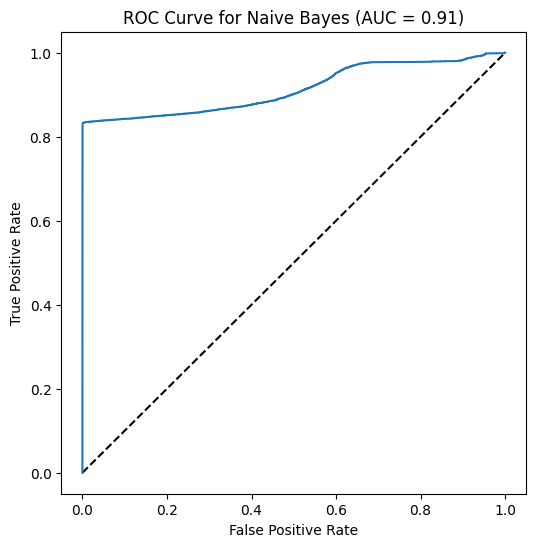

AUC: 0.91


In [87]:
nb = GaussianNB()
nb.fit(X_train, y_train)
evaluate_model(nb, X_test, y_test, "Naive Bayes")

In [88]:
def objective_nb(trial):
    var_smoothing = trial.suggest_loguniform('var_smoothing', 1e-10, 1e-5)
    model = GaussianNB(var_smoothing=var_smoothing)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()

[I 2025-06-05 19:30:34,906] A new study created in memory with name: no-name-7d7c2af8-8ecc-4469-83f3-a00d7d815cc4
C:\Users\andre\AppData\Local\Temp\ipykernel_21744\557947750.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  var_smoothing = trial.suggest_loguniform('var_smoothing', 1e-10, 1e-5)
[I 2025-06-05 19:30:34,993] Trial 0 finished with value: 0.9125584343996375 and parameters: {'var_smoothing': 8.260348576501791e-08}. Best is trial 0 with value: 0.9125584343996375.
C:\Users\andre\AppData\Local\Temp\ipykernel_21744\557947750.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  var_smoothing = trial.suggest_loguniform('var_smoothing', 1e-10, 1e-5)
[I 2025-06-05 19

Лучшие параметры для Naive Bayes: {'var_smoothing': 8.260348576501791e-08}

--- Naive Bayes (Optimized) ---
Classification Report:
              precision    recall  f1-score   support

       False       0.86      0.98      0.92     13428
        True       0.98      0.84      0.90     13427

    accuracy                           0.91     26855
   macro avg       0.92      0.91      0.91     26855
weighted avg       0.92      0.91      0.91     26855

Confusion Matrix:
[[13192   236]
 [ 2207 11220]]
F1-score: 0.9018


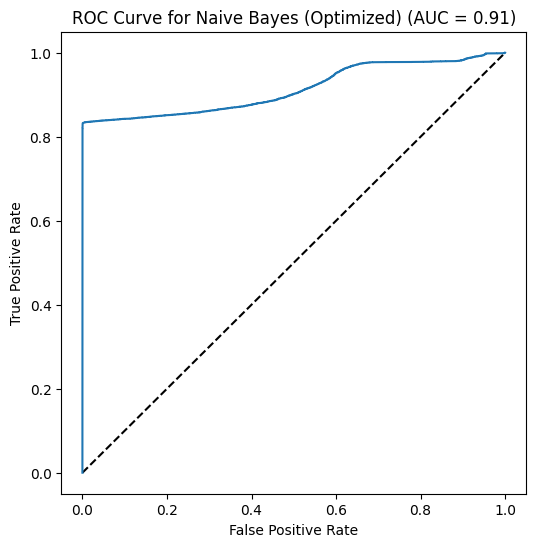

AUC: 0.91


In [89]:
study_nb = optuna.create_study(direction='maximize')
study_nb.optimize(objective_nb, n_trials=50)
print("Лучшие параметры для Naive Bayes:", study_nb.best_params)
nb_best = GaussianNB(**study_nb.best_params)
nb_best.fit(X_train, y_train)
evaluate_model(nb_best, X_test, y_test, "Naive Bayes (Optimized)")

### KNN


--- KNN ---
Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855

Confusion Matrix:
[[13403    25]
 [   38 13389]]
F1-score: 0.9977


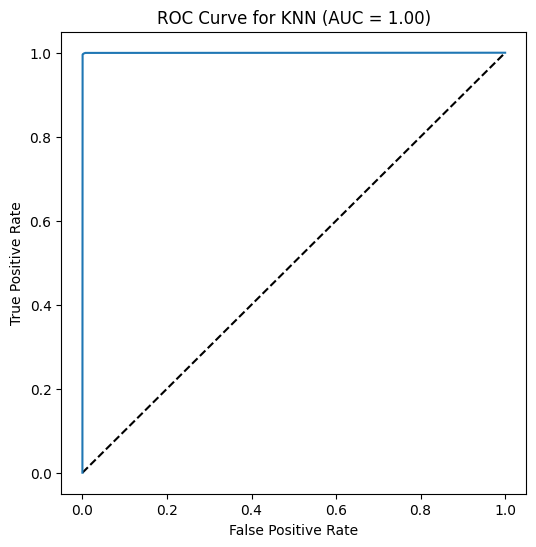

AUC: 1.00


In [90]:
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn.fit(X_train, y_train)
evaluate_model(knn, X_test, y_test, "KNN")

In [91]:
def objective_knn(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 15)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski', 'chebyshev'])
    p = trial.suggest_int('p', 1, 5) if metric == 'minkowski' else 2
    model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric, p=p)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()

[I 2025-06-05 19:30:41,142] A new study created in memory with name: no-name-202d4328-eb8a-494f-981e-50c83458c560
[I 2025-06-05 19:30:42,940] Trial 0 finished with value: 0.9951962185169225 and parameters: {'n_neighbors': 13, 'weights': 'distance', 'metric': 'chebyshev'}. Best is trial 0 with value: 0.9951962185169225.
[I 2025-06-05 19:30:46,190] Trial 1 finished with value: 0.9957548038604447 and parameters: {'n_neighbors': 15, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 1 with value: 0.9957548038604447.
[I 2025-06-05 19:30:49,435] Trial 2 finished with value: 0.9988828458694063 and parameters: {'n_neighbors': 5, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 2 with value: 0.9988828458694063.
[I 2025-06-05 19:30:50,883] Trial 3 finished with value: 0.9966804457088138 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'metric': 'chebyshev'}. Best is trial 2 with value: 0.9988828458694063.
[I 2025-06-05 19:30:53,874] Trial 4 finished with value: 0.997

Лучшие параметры для KNN: {'n_neighbors': 3, 'weights': 'uniform', 'metric': 'manhattan'}

--- KNN (Optimized) ---
Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855

Confusion Matrix:
[[13416    12]
 [   15 13412]]
F1-score: 0.9990


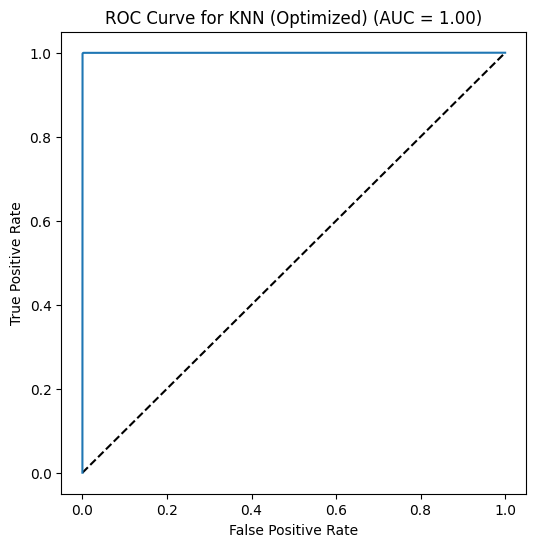

AUC: 1.00


In [92]:
study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=50)
print("Лучшие параметры для KNN:", study_knn.best_params)
knn_best = KNeighborsClassifier(**study_knn.best_params)
knn_best.fit(X_train, y_train)
evaluate_model(knn_best, X_test, y_test, "KNN (Optimized)")

### SVM

In [93]:
X_small, y_small = resample(X_train, y_train, n_samples=5000, random_state=42, replace=False)

In [94]:
def exponential_kernel(X, Y):
    gamma = 0.1
    return np.exp(-gamma * pairwise_distances(X, Y, metric='euclidean'))


--- SVM (Exponential Kernel) ---
Classification Report:
              precision    recall  f1-score   support

       False       0.98      1.00      0.99     13428
        True       1.00      0.98      0.99     13427

    accuracy                           0.99     26855
   macro avg       0.99      0.99      0.99     26855
weighted avg       0.99      0.99      0.99     26855

Confusion Matrix:
[[13397    31]
 [  330 13097]]
F1-score: 0.9864


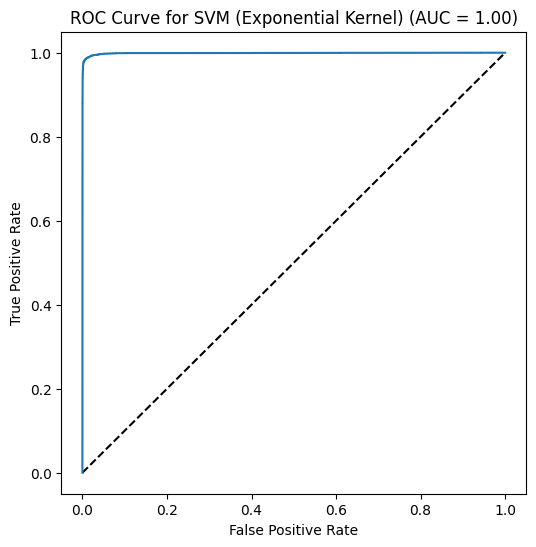

AUC: 1.00


In [95]:
svc_exp = SVC(kernel=exponential_kernel, probability=True)
svc_exp.fit(X_small, y_small)
evaluate_model(svc_exp, X_test, y_test, "SVM (Exponential Kernel)")


--- SVM (linear Kernel) ---
Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.95      0.91     13428
        True       0.95      0.87      0.91     13427

    accuracy                           0.91     26855
   macro avg       0.91      0.91      0.91     26855
weighted avg       0.91      0.91      0.91     26855

Confusion Matrix:
[[12796   632]
 [ 1785 11642]]
F1-score: 0.9060


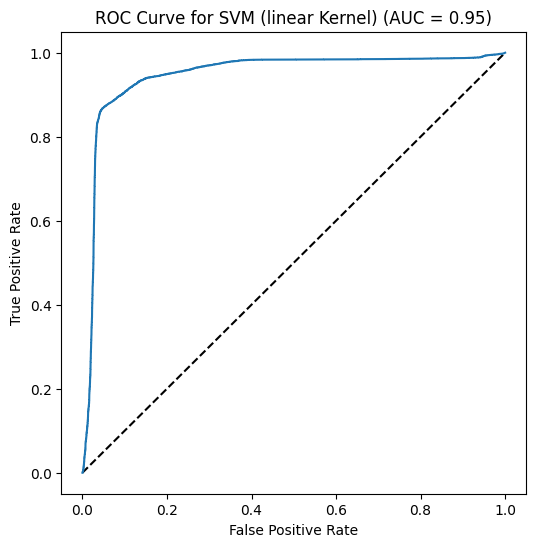

AUC: 0.95

--- SVM (poly Kernel) ---
Classification Report:
              precision    recall  f1-score   support

       False       0.59      1.00      0.74     13428
        True       0.99      0.31      0.47     13427

    accuracy                           0.65     26855
   macro avg       0.79      0.65      0.60     26855
weighted avg       0.79      0.65      0.60     26855

Confusion Matrix:
[[13371    57]
 [ 9323  4104]]
F1-score: 0.4667


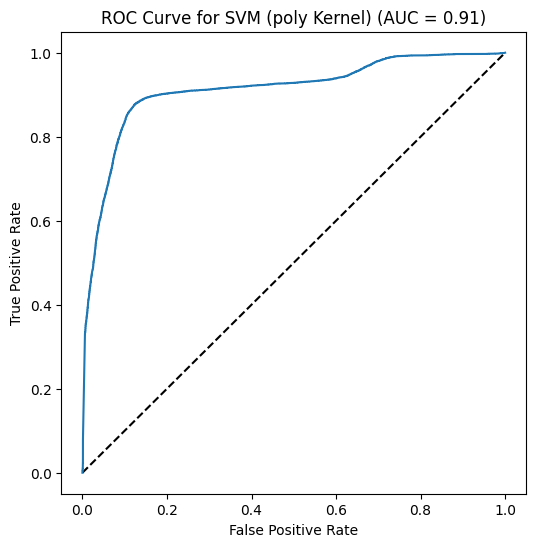

AUC: 0.91

--- SVM (rbf Kernel) ---
Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.99      0.94     13428
        True       0.99      0.90      0.94     13427

    accuracy                           0.94     26855
   macro avg       0.95      0.94      0.94     26855
weighted avg       0.95      0.94      0.94     26855

Confusion Matrix:
[[13250   178]
 [ 1366 12061]]
F1-score: 0.9398


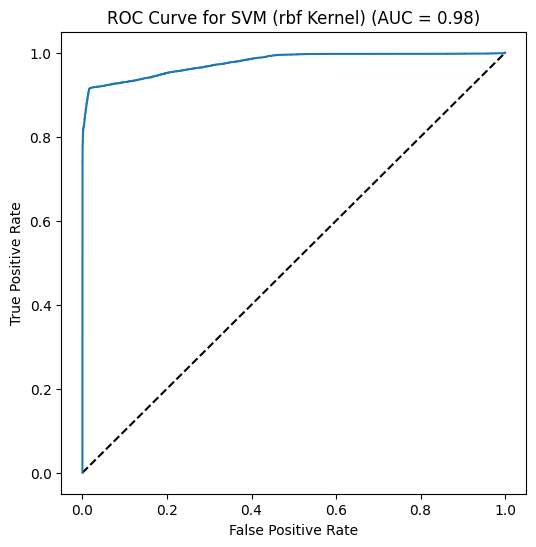

AUC: 0.98

--- SVM (sigmoid Kernel) ---
Classification Report:
              precision    recall  f1-score   support

       False       0.77      0.74      0.75     13428
        True       0.75      0.77      0.76     13427

    accuracy                           0.76     26855
   macro avg       0.76      0.76      0.76     26855
weighted avg       0.76      0.76      0.76     26855

Confusion Matrix:
[[ 9942  3486]
 [ 3027 10400]]
F1-score: 0.7615


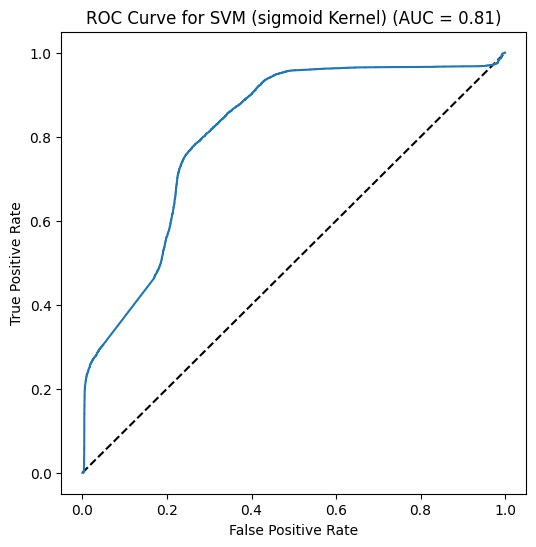

AUC: 0.81


In [96]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
    svc = SVC(kernel=kernel, probability=True, random_state=42)
    svc.fit(X_small, y_small)
    evaluate_model(svc, X_test, y_test, f"SVM ({kernel} Kernel)")

### KNN KFold 

In [97]:
scores = cross_val_score(knn_best, X_scaled, y, cv=kfold, scoring='accuracy')
print("Кросс-валидация (k-fold):")
print(f"Точность для каждого фолда: {scores}")
print(f"Средняя точность: {np.mean(scores):.4f}")
print(f"Стандартное отклонение: {np.std(scores):.4f}")

Кросс-валидация (k-fold):
Точность для каждого фолда: [0.99944143 0.99921801 0.99944143 0.99944143 0.99921796]
Средняя точность: 0.9994
Стандартное отклонение: 0.0001


### KNN моя цена

In [99]:
knn = KNNHandMade(n_neighbors=3, metric='manhattan', weights='uniform')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00     13428
        True       1.00      1.00      1.00     13427

    accuracy                           1.00     26855
   macro avg       1.00      1.00      1.00     26855
weighted avg       1.00      1.00      1.00     26855

